<a href="https://colab.research.google.com/github/Girisha-Malni-builds01/QFIM-/blob/main/QFIM_VQC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QFIM-Guided Variational Quantum Classifier — Qiskit Prototype

**Paper-faithful hackathon implementation**

- Dataset: Wisconsin Diagnostic Breast Cancer (WDBC)
- Classical front-end: StandardScaler → PCA(4)
- Quantum encoding: RX–RY–RZ
- Ansatz: 4 qubits × 2 layers, RX–RY–RZ + ring CNOT
- Quantum parameters: 24
- Optimization: Quantum Natural Gradient (QNG) using the QFIM
- Diagnostic: post-training QFIM spectrum, trace, rank, effective dimension and condition number
- Optional execution: IBM Quantum backend

This notebook is deliberately compact. It separates the **quantum ansatz parameters (24)** from the **classical readout parameters (4 weights + bias)** so the reported QFIM remains a 24×24 object, matching the paper's parameter count.


In [1]:
# Colab setup — current Qiskit stack
%pip -q install "qiskit~=2.5.2" "qiskit-aer>=0.17.2" "qiskit-ibm-runtime>=0.50.0" scikit-learn pandas matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.3/113.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.0/131.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.

In [2]:
import sys, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.linear_model import LogisticRegression

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector, SparsePauliOp

SEED = 42
rng = np.random.default_rng(SEED)

N_QUBITS = 4
N_LAYERS = 2
N_QPARAMS = N_QUBITS * 3 * N_LAYERS

# Fast hackathon defaults. Set DEMO_MODE=False for a larger run.
DEMO_MODE = True
EPOCHS = 12 if DEMO_MODE else 30
BATCH_SIZE = 64 if DEMO_MODE else 128
QFIM_SAMPLES = 8 if DEMO_MODE else 20
LR_QNG = 0.08
LR_READOUT = 0.05
DAMPING = 1e-2

print("Qiskit:", __import__("qiskit").__version__)
print("Quantum parameters:", N_QPARAMS)


Qiskit: 2.5.2
Quantum parameters: 24


## 1. Data pipeline

The paper uses 569 samples, 30 features, an 80/20 split, StandardScaler and PCA to four components. Labels are mapped to **0 = benign, 1 = malignant** for the classifier.


In [3]:
data = load_breast_cancer(as_frame=True)
X = data.data.to_numpy(dtype=float)
# sklearn: target 0=malignant, 1=benign → invert to paper-style malignant-positive label
y = (1 - data.target.to_numpy()).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

pca = PCA(n_components=N_QUBITS, random_state=SEED)
X_train_p = pca.fit_transform(X_train_s)
X_test_p = pca.transform(X_test_s)

# Paper scales each reduced feature to [0, pi].
pca_min = X_train_p.min(axis=0)
pca_max = X_train_p.max(axis=0)
X_train_q = np.pi * (X_train_p - pca_min) / (pca_max - pca_min + 1e-12)
X_test_q = np.pi * (X_test_p - pca_min) / (pca_max - pca_min + 1e-12)

# Keep an untouched validation slice from the training set for demo monitoring.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_q, y_train, test_size=0.20, random_state=SEED, stratify=y_train
)

print(f"Train: {len(X_tr)} | Validation: {len(X_val)} | Test: {len(X_test_q)}")
print("PCA explained variance:", np.round(pca.explained_variance_ratio_, 4))


Train: 364 | Validation: 91 | Test: 114
PCA explained variance: [0.4459 0.1855 0.0958 0.0659]


## 2. Qiskit circuit

The circuit follows the paper's reference architecture: RX–RY–RZ data encoding, followed by two trainable RX–RY–RZ layers and a ring of CNOT gates.


In [4]:
x_params = ParameterVector("x", N_QUBITS)
theta_params = ParameterVector("θ", N_QPARAMS)

def build_circuit():
    qc = QuantumCircuit(N_QUBITS)

    # RX-RY-RZ product-state data encoding
    for q in range(N_QUBITS):
        qc.rx(x_params[q], q)
        qc.ry(x_params[q], q)
        qc.rz(x_params[q], q)

    k = 0
    for _ in range(N_LAYERS):
        for q in range(N_QUBITS):
            qc.rx(theta_params[k], q); k += 1
            qc.ry(theta_params[k], q); k += 1
            qc.rz(theta_params[k], q); k += 1

        # ring: q0→q1→q2→q3→q0
        for q in range(N_QUBITS - 1):
            qc.cx(q, q + 1)
        qc.cx(N_QUBITS - 1, 0)

    return qc

QC = build_circuit()
print(QC.draw("text"))
print("Parameters:", len(QC.parameters), "| trainable θ:", N_QPARAMS)


     ┌──────────┐┌──────────┐┌──────────┐┌──────────┐ ┌──────────┐ ┌──────────┐»
q_0: ┤ Rx(x[0]) ├┤ Ry(x[0]) ├┤ Rz(x[0]) ├┤ Rx(θ[0]) ├─┤ Ry(θ[1]) ├─┤ Rz(θ[2]) ├»
     ├──────────┤├──────────┤├──────────┤├──────────┤ ├──────────┤ ├──────────┤»
q_1: ┤ Rx(x[1]) ├┤ Ry(x[1]) ├┤ Rz(x[1]) ├┤ Rx(θ[3]) ├─┤ Ry(θ[4]) ├─┤ Rz(θ[5]) ├»
     ├──────────┤├──────────┤├──────────┤├──────────┤ ├──────────┤ ├──────────┤»
q_2: ┤ Rx(x[2]) ├┤ Ry(x[2]) ├┤ Rz(x[2]) ├┤ Rx(θ[6]) ├─┤ Ry(θ[7]) ├─┤ Rz(θ[8]) ├»
     ├──────────┤├──────────┤├──────────┤├──────────┤┌┴──────────┤┌┴──────────┤»
q_3: ┤ Rx(x[3]) ├┤ Ry(x[3]) ├┤ Rz(x[3]) ├┤ Rx(θ[9]) ├┤ Ry(θ[10]) ├┤ Rz(θ[11]) ├»
     └──────────┘└──────────┘└──────────┘└──────────┘└───────────┘└───────────┘»
«                            ┌───┐┌───────────┐┌───────────┐┌───────────┐     »
«q_0: ──■────────────────────┤ X ├┤ Rx(θ[12]) ├┤ Ry(θ[13]) ├┤ Rz(θ[14]) ├──■──»
«     ┌─┴─┐     ┌───────────┐└─┬─┘├───────────┤├───────────┤└───────────┘┌─┴─┐»
«q_1: ┤ X ├──■──┤ Rx(θ[15]) ├──

In [5]:
# Pauli-Z observables for the four readout features
Z_OPS = []
for q in range(N_QUBITS):
    label = ["I"] * N_QUBITS
    label[N_QUBITS - 1 - q] = "Z"   # Qiskit Pauli-string ordering
    Z_OPS.append(SparsePauliOp.from_list([("".join(label), 1.0)]))

def state_for(x, theta):
    values = {x_params[i]: float(x[i]) for i in range(N_QUBITS)}
    values.update({theta_params[i]: float(theta[i]) for i in range(N_QPARAMS)})
    return Statevector.from_instruction(QC.assign_parameters(values))

def z_expectations_from_state(sv):
    return np.array([float(np.real(sv.expectation_value(op))) for op in Z_OPS])

def forward_z(x, theta):
    return z_expectations_from_state(state_for(x, theta))

def sigmoid(z):
    z = np.clip(z, -40, 40)
    return 1.0 / (1.0 + np.exp(-z))

def class_weights(y):
    n = len(y)
    return np.array([n / (2 * np.sum(y == c)) for c in (0, 1)])

W_CLASS = class_weights(y_tr)
print("Class weights [0,1]:", W_CLASS)


Class weights [0,1]: [0.79824561 1.33823529]


## 3. Parameter-shift derivatives

For the RX/RY/RZ trainable rotations, the derivative of the state is obtained with the exact parameter-shift identity

\[
|\partial_i\psi
angle =
\frac{1}{2}\left(|\psi(\theta_i+\pi/2)\rangle-
|\psi(\theta_i-\pi/2)\rangle
ight).
\]

The same derivatives are reused for the QNG gradient and QFIM, avoiding a second derivative implementation.


In [6]:
SHIFT = np.pi / 2

def shifted_state(x, theta, i, shift):
    t = np.asarray(theta, dtype=float).copy()
    t[i] += shift
    return state_for(x, t)

def parameter_derivative_states(x, theta):
    derivs = []
    for i in range(N_QPARAMS):
        plus = shifted_state(x, theta, i, +SHIFT).data
        minus = shifted_state(x, theta, i, -SHIFT).data
        derivs.append(0.5 * (plus - minus))
    return np.asarray(derivs)

def z_and_dz(x, theta):
    base = state_for(x, theta)
    z = z_expectations_from_state(base)
    dz = np.zeros((N_QPARAMS, N_QUBITS))

    # d<Z>/dθ = 2 Re(<dψ|Z|ψ>)
    psi = base.data
    for i, dpsi in enumerate(parameter_derivative_states(x, theta)):
        for q, op in enumerate(Z_OPS):
            zpsi = op.to_matrix() @ psi
            dz[i, q] = 2.0 * np.real(np.vdot(dpsi, zpsi))
    return z, dz


In [9]:
def batch_forward(X, theta, w, b, need_derivatives=False):
    """Evaluates expectations and optionally parameter-shift derivatives for a batch of samples."""
    n_samples = len(X)
    Z = np.zeros((n_samples, N_QUBITS))

    if not need_derivatives:
        for idx, x in enumerate(X):
            Z[idx] = forward_z(x, theta)
        return Z

    dZ = np.zeros((n_samples, N_QPARAMS, N_QUBITS))
    for idx, x in enumerate(X):
        z, dz = z_and_dz(x, theta)
        Z[idx] = z
        dZ[idx] = dz
    return Z, dZ

## 4. QFIM

For a pure state,

\[
F_{ij}=4\,\mathrm{Re}
\left[
\langle\partial_i\psi|\partial_j\psi
angle
-\langle\partial_i\psi|\psi
angle
\langle\psi|\partial_j\psi
angle

ight].
\]

The implementation averages the QFIM over a small training subset, as the paper does for computational stability, then adds λI before inversion.


In [7]:
def qfim_single(x, theta):
    psi = state_for(x, theta).data
    D = parameter_derivative_states(x, theta)

    gram = D.conj() @ D.T
    overlaps = D.conj() @ psi
    F = 4.0 * np.real(gram - np.outer(overlaps, overlaps.conj()))
    F = 0.5 * (F + F.T)
    return F

def qfim_batch(X, theta):
    F = np.zeros((N_QPARAMS, N_QPARAMS))
    for x in X:
        F += qfim_single(x, theta)
    F /= len(X)
    return 0.5 * (F + F.T)

def qfim_metrics(F):
    F = 0.5 * (F + F.T)
    eigvals = np.linalg.eigvalsh(F)
    eigvals = np.maximum(eigvals, 0.0)
    lmax = float(eigvals.max())
    eps_rel = 1e-2 * lmax
    # Numerical rank and the paper-defined thresholded effective dimension are distinct.
    rank = int(np.sum(eigvals > 1e-10))
    effective_dim = int(np.sum(eigvals > max(eps_rel, 1e-12)))
    # Condition number follows λmax / λmin with a tiny numerical floor.
    condition = lmax / max(float(eigvals.min()), 1e-12)
    return {
        "trace": float(np.trace(F)),
        "rank": rank,
        "effective_dimension": effective_dim,
        "condition_number": float(condition),
        "largest_eigenvalue": lmax,
        "smallest_eigenvalue": float(eigvals.min()),
        "eigenvalues": eigvals
    }


## 5. QNG training

The quantum circuit has 24 trainable parameters. The classical readout has four coefficients and one bias:

\[
s=w^T\langle Z
angle+b,\qquad \hat y=\sigma(s).
\]

QNG is applied to the 24 quantum parameters; the readout is updated with the ordinary BCE gradient. This makes the parameter accounting explicit.


In [10]:
def weighted_bce(y, p, weights=W_CLASS):
    p = np.clip(p, 1e-7, 1 - 1e-7)
    sample_w = np.where(y == 1, weights[1], weights[0])
    return float(np.mean(-sample_w * (y*np.log(p) + (1-y)*np.log(1-p))))

def predict_proba(X, theta, w, b):
    Z = batch_forward(X, theta, w, b)
    return sigmoid(Z @ w + b)

def train_qng(X, y, X_val, y_val):
    theta = rng.normal(0.0, 0.05, N_QPARAMS)
    w = np.ones(N_QUBITS) / N_QUBITS
    b = 0.0

    history = {"loss": [], "train_acc": [], "val_acc": [], "qfim_cond": []}

    for epoch in range(EPOCHS):
        idx = rng.choice(len(X), size=min(BATCH_SIZE, len(X)), replace=False)
        xb, yb = X[idx], y[idx]

        Z, dZ = batch_forward(xb, theta, w, b, need_derivatives=True)
        p = sigmoid(Z @ w + b)

        sample_w = np.where(yb == 1, W_CLASS[1], W_CLASS[0])
        err = (p - yb) * sample_w / len(yb)

        grad_w = Z.T @ err
        grad_b = np.sum(err)

        # d logit / d theta_i = sum_q w_q d<Z_q>/d theta_i
        dlogits = np.einsum("q,biq->bi", w, dZ)
        grad_theta = np.sum(err[:, None] * dlogits, axis=0)

        qidx = idx[:min(QFIM_SAMPLES, len(idx))]
        F = qfim_batch(X[qidx], theta)
        F_reg = F + DAMPING * np.eye(N_QPARAMS)
        nat_grad = np.linalg.pinv(F_reg, rcond=1e-10) @ grad_theta

        theta -= LR_QNG * nat_grad
        w -= LR_READOUT * grad_w
        b -= LR_READOUT * grad_b

        train_p = predict_proba(X, theta, w, b)
        val_p = predict_proba(X_val, theta, w, b)

        history["loss"].append(weighted_bce(yb, p))
        history["train_acc"].append(accuracy_score(y, train_p >= 0.5))
        history["val_acc"].append(accuracy_score(y_val, val_p >= 0.5))
        history["qfim_cond"].append(qfim_metrics(F)["condition_number"])

        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"epoch {epoch+1:02d}/{EPOCHS} | loss {history['loss'][-1]:.4f} | "
                  f"train {history['train_acc'][-1]:.3f} | val {history['val_acc'][-1]:.3f}")

    return theta, w, b, history

t0 = time.time()
theta_star, w_star, b_star, history = train_qng(X_tr, y_tr, X_val, y_val)
print(f"Training time: {time.time()-t0:.1f}s")

epoch 01/12 | loss 0.7311 | train 0.374 | val 0.374
epoch 02/12 | loss 0.7206 | train 0.374 | val 0.374
epoch 04/12 | loss 0.6832 | train 0.382 | val 0.385
epoch 06/12 | loss 0.7051 | train 0.396 | val 0.374
epoch 08/12 | loss 0.6642 | train 0.415 | val 0.385
epoch 10/12 | loss 0.6988 | train 0.398 | val 0.396
epoch 12/12 | loss 0.7018 | train 0.426 | val 0.385
Training time: 155.8s


## 6. Training diagnostics

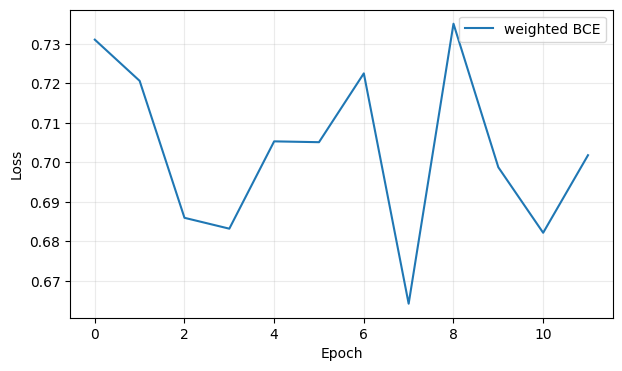

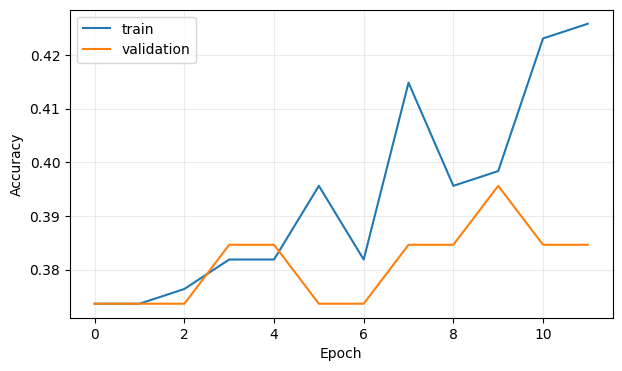

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["loss"], label="weighted BCE")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["train_acc"], label="train")
ax.plot(history["val_acc"], label="validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


## 7. Test evaluation and threshold selection

The operating threshold is selected on the validation set, not the test set. This prevents threshold tuning from leaking test information.


In [12]:
val_prob = predict_proba(X_val, theta_star, w_star, b_star)

thresholds = np.linspace(0.20, 0.80, 61)
val_rows = []
for tau in thresholds:
    pred = (val_prob >= tau).astype(int)
    val_rows.append({
        "threshold": tau,
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
    })
val_df = pd.DataFrame(val_rows)
tau_star = float(val_df.loc[val_df["f1"].idxmax(), "threshold"])
print("Selected validation threshold:", tau_star)

test_prob = predict_proba(X_test_q, theta_star, w_star, b_star)
test_pred = (test_prob >= tau_star).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
specificity = tn / (tn + fp)

metrics = {
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall / Sensitivity": recall_score(y_test, test_pred, zero_division=0),
    "Specificity": specificity,
    "F1": f1_score(y_test, test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_prob),
}
pd.Series(metrics).round(4)


Selected validation threshold: 0.2


,0
Accuracy,0.3684
Precision,0.3684
Recall / Sensitivity,1.0000
Specificity,0.0000
F1,0.5385
ROC-AUC,0.3112


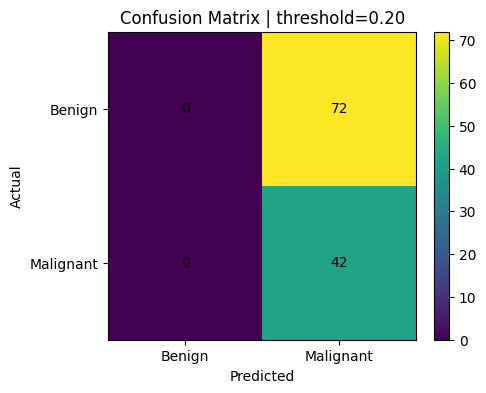

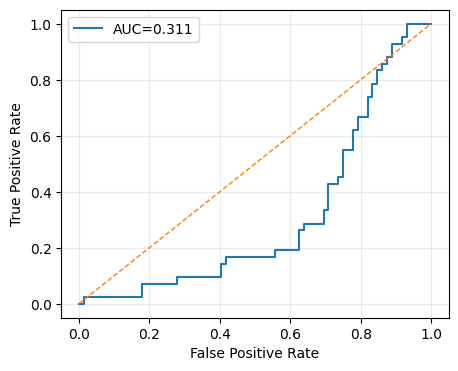

In [13]:
cm = confusion_matrix(y_test, test_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm)
ax.set_xticks([0,1], ["Benign", "Malignant"])
ax.set_yticks([0,1], ["Benign", "Malignant"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix | threshold={tau_star:.2f}")
for (i,j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

fpr, tpr, _ = roc_curve(y_test, test_prob)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f"AUC={metrics['ROC-AUC']:.3f}")
ax.plot([0,1], [0,1], "--", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


## 8. Post-training QFIM

This is the core research diagnostic. The final QFIM is evaluated at the trained quantum parameters and averaged over the diagnostic subset.


trace                    35.421089
rank                     24.000000
effective_dimension      21.000000
condition_number       1145.607970
largest_eigenvalue        4.216917
smallest_eigenvalue       0.003681
dtype: float64


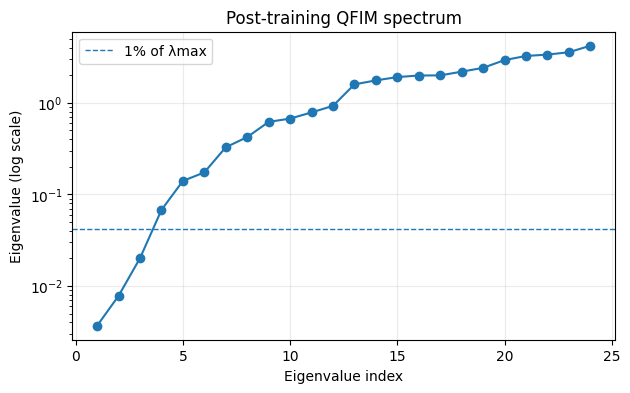

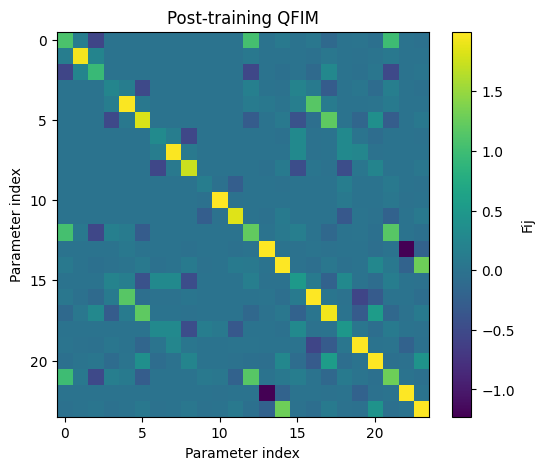

In [14]:
diag_idx = rng.choice(len(X_tr), size=min(20, len(X_tr)), replace=False)
F_star = qfim_batch(X_tr[diag_idx], theta_star)
qstats = qfim_metrics(F_star)

print(pd.Series({k:v for k,v in qstats.items() if k != "eigenvalues"}).round(6))

eig = qstats["eigenvalues"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(np.arange(1, len(eig)+1), np.maximum(eig, 1e-12), "o-")
ax.axhline(1e-2 * eig.max(), linestyle="--", linewidth=1, label="1% of λmax")
ax.set_xlabel("Eigenvalue index")
ax.set_ylabel("Eigenvalue (log scale)")
ax.set_title("Post-training QFIM spectrum")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(F_star, aspect="auto")
ax.set_xlabel("Parameter index")
ax.set_ylabel("Parameter index")
ax.set_title("Post-training QFIM")
plt.colorbar(im, ax=ax, label="Fij")
plt.show()


## 9. QFIM stability check

A small perturbation test checks whether the spectrum is dominated by numerical noise.


In [15]:
perturb = 1e-3 * rng.normal(size=N_QPARAMS)
F_pert = qfim_batch(X_tr[diag_idx], theta_star + perturb)
e0 = qfim_metrics(F_star)["eigenvalues"]
e1 = qfim_metrics(F_pert)["eigenvalues"]

rel_spectrum_change = np.linalg.norm(e1 - e0) / max(np.linalg.norm(e0), 1e-12)
symmetry_error = np.linalg.norm(F_star - F_star.T)
min_eig = np.linalg.eigvalsh(F_star).min()

print(f"QFIM symmetry error: {symmetry_error:.3e}")
print(f"Minimum eigenvalue before clipping: {min_eig:.3e}")
print(f"Relative spectrum change under 1e-3 perturbation: {rel_spectrum_change:.3e}")


QFIM symmetry error: 0.000e+00
Minimum eigenvalue before clipping: 3.681e-03
Relative spectrum change under 1e-3 perturbation: 6.199e-04


## 10. Classical reference

The paper itself reports classical models substantially above the compact VQC. That comparison is important: the prototype should demonstrate the **information-geometric quantum workflow**, not claim quantum advantage on WDBC.


In [16]:
lr = LogisticRegression(max_iter=5000, random_state=SEED)
lr.fit(X_train_s, y_train)
lr_prob = lr.predict_proba(X_test_s)[:, 1]
lr_pred = (lr_prob >= 0.5).astype(int)

print({
    "Logistic Regression accuracy": round(accuracy_score(y_test, lr_pred), 4),
    "Logistic Regression F1": round(f1_score(y_test, lr_pred), 4),
    "Logistic Regression ROC-AUC": round(roc_auc_score(y_test, lr_prob), 4),
})


{'Logistic Regression accuracy': 0.9649, 'Logistic Regression F1': 0.9512, 'Logistic Regression ROC-AUC': np.float64(0.996)}


## 11. Architectural micro-ablation

This is intentionally lightweight for a hackathon. It tests the three design axes in the paper without pretending to reproduce every full ablation table.

Change one variable at a time and retrain if desired:
- encoding: RX / RX+RY / RX+RY+RZ
- entanglement: none / linear / ring
- depth: 1 / 2 / 3

The reference implementation below exposes those choices cleanly.


In [17]:
def build_circuit_config(encoding=("rx","ry","rz"), depth=2, topology="ring"):
    xp = ParameterVector("x", N_QUBITS)
    tp = ParameterVector("θ", N_QUBITS * 3 * depth)
    qc = QuantumCircuit(N_QUBITS)

    for q in range(N_QUBITS):
        if "rx" in encoding: qc.rx(xp[q], q)
        if "ry" in encoding: qc.ry(xp[q], q)
        if "rz" in encoding: qc.rz(xp[q], q)

    k = 0
    for _ in range(depth):
        for q in range(N_QUBITS):
            qc.rx(tp[k], q); k += 1
            qc.ry(tp[k], q); k += 1
            qc.rz(tp[k], q); k += 1

        if topology == "linear":
            for q in range(N_QUBITS - 1):
                qc.cx(q, q+1)
        elif topology == "ring":
            for q in range(N_QUBITS - 1):
                qc.cx(q, q+1)
            qc.cx(N_QUBITS - 1, 0)

    return qc

print("Reference:", build_circuit_config().num_parameters, "total parameters")
print("Depth-1 :", build_circuit_config(depth=1).num_parameters, "total parameters")
print("Depth-3 :", build_circuit_config(depth=3).num_parameters, "total parameters")


Reference: 28 total parameters
Depth-1 : 16 total parameters
Depth-3 : 40 total parameters


## 12. IBM Quantum execution — optional

The training above is local and deterministic. This section sends the **trained parameterized circuit** to an IBM backend for measured expectation values.

Do not reuse the pure-state QFIM formula on noisy hardware results. Hardware execution is used here as an experimental validation layer; the pure-state QFIM remains the ideal-state geometry diagnostic.


In [ ]:

from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(
     channel="ibm_cloud",
     token="YOUR_IBM_QUANTUM_TOKEN",
     overwrite=True
 )


In [ ]:
# Current IBM Runtime client: prefer the current client-side Estimator.
# The exact backend availability changes over time, so choose one interactively.
#
# from qiskit_ibm_runtime import QiskitRuntimeService, Estimator
#
# service = QiskitRuntimeService()
# backends = service.backends(simulator=False, operational=True, min_num_qubits=4)
# [(b.name, b.num_qubits) for b in backends[:10]]


In [ ]:
# Example hardware inference for one sample.
# Run only after selecting an operational IBM backend.
#
# backend = service.backend("YOUR_BACKEND")
# estimator = Estimator(mode=backend)
#
# # Build one parameterized circuit and four Z observables.
# # For hardware, use the backend's transpiler/pass manager before execution.
# from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
#
# pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
# isa_qc = pm.run(QC)
# isa_obs = [op.apply_layout(isa_qc.layout) for op in Z_OPS]
#
# x0 = X_test_q[0]
# values = {x_params[i]: float(x0[i]) for i in range(N_QUBITS)}
# values.update({theta_params[i]: float(theta_star[i]) for i in range(N_QPARAMS)})
#
# pubs = [(isa_qc, obs, [values]) for obs in isa_obs]
# job = estimator.run(pubs, precision=0.05)
# result = job.result()
# z_hw = np.array([float(np.asarray(r.data.evs).reshape(-1)[0]) for r in result])
# p_hw = float(sigmoid(z_hw @ w_star + b_star))
# print("Hardware Z expectations:", z_hw)
# print("Hardware malignant probability:", p_hw)


## 13. One-command demo summary

Run this cell last for a clean hackathon screen.


In [ ]:
summary = {
    "Qubits": N_QUBITS,
    "Quantum parameters": N_QPARAMS,
    "Layers": N_LAYERS,
    "Encoding": "RX-RY-RZ",
    "Entanglement": "Ring CNOT",
    "Optimizer": "QNG / QFIM",
    "QFIM trace": qstats["trace"],
    "QFIM rank": qstats["rank"],
    "Effective dimension": qstats["effective_dimension"],
    "Condition number": qstats["condition_number"],
    "Test accuracy": metrics["Accuracy"],
    "Test sensitivity": metrics["Recall / Sensitivity"],
    "Test specificity": metrics["Specificity"],
    "Test F1": metrics["F1"],
    "Test ROC-AUC": metrics["ROC-AUC"],
    "Threshold": tau_star,
}
pd.Series(summary)
